<a href="https://colab.research.google.com/github/MdMukidurRahman/MdMukidurRahman/blob/main/Copy_of_CIS_530_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIS530 Final Project Assignment
**Name:** _Md Mukidur Rahman_

Welcome to your individual assignment based on the *Dig* dataset from the book *Python for MBAs*. You will analyze the Dig case data to answer a unique business question using Python and pandas.

This assignment is worth 25 points and will 'count' for your Quizzes 5-8 in the course.

> 📝 **Instructions:**
>
> - Replace placeholders with your assigned business question.
> - Include comments in your code to explain what each step does.
> - Submit your completed notebook as a `.ipynb` file the Final Project Assignment link in Brightspace

## 📌 Your Assigned Question
> Replace the text below with **your specific question** from the assignment document:

**Question**: _Which items have the most variable usage, and what might that imply about supply chain stability?_  

## 📂 Load and Inspect the Data

In this section, you will load one (or more) of the four key data sets:
- `Restaurants.csv`
- `Items.csv`
- `Simplified orders.csv`
- `Summarized orders.csv`

You can just import the data sets you need for your specific problem. You do not have to import any data that you do not need.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_items = pd.read_csv('/content/drive/MyDrive/CIS530 Data/Items.csv')
df_orders = pd.read_csv('/content/drive/MyDrive/CIS530 Data/Simplified orders.csv')
# create any data frames you need

# preview data if you wish
print(df_items.head())
print(df_orders.head())

  ITEM_ID                             ITEM_NAME     ITEM_TYPE
0      I7          Farro with Summer Vegetables         Bases
1     I39                       Spindrift Lemon        Drinks
2      I5                    Classic Brown Rice         Bases
3     I36                              Kombucha        Drinks
4      I8  Cauliflower with Garlic and Parmesan  Market Sides
   ORDER_ID             DATETIME RESTAURANT_ID      TYPE  DRINKS  COOKIES  \
0  O1820060  2018-10-11 17:25:50        R10002  IN_STORE     1.0      2.0   
1  O1011112  2018-05-31 11:35:00        R10003  IN_STORE     0.0      0.0   
2   O752854  2018-04-21 18:12:57        R10001  DELIVERY     0.0      2.0   
3  O2076864  2018-11-17 12:50:52        R10005    PICKUP     1.0      0.0   
4  O1988898  2018-11-04 18:37:24        R10008  IN_STORE     0.0      0.0   

  MAIN BASE SIDE_1 SIDE_2  
0  NaN  NaN    NaN    NaN  
1  NaN  NaN    NaN    NaN  
2   I0   I7    I15    I14  
3   I0   I5     I9    I12  
4   I1   I7     I9     I9

## 📈 Analysis 10 points

This is the core of your work. Use appropriate pandas operations, filters, aggregations,visualizations, and any data frames that need to be merged to answer your assigned question.

***Before you Begin:*** Only use Python or pandas functions from Chapters 5-7 in our text Python for MBAs. If you use any other functions or code that is not specifically from our text, a minimum of 5 points/marks will be deducted for this part of the assignment.

In [ ]:
# your analysis code goes here
# Stack all item columns into one column
item_cols = ['MAIN', 'BASE', 'SIDE_1', 'SIDE_2']
df_items_used = df_orders[item_cols].stack().reset_index(drop=True).to_frame(name='ITEM_ID')

# Count item usage
item_usage = df_items_used['ITEM_ID'].value_counts().reset_index()
item_usage.columns = ['ITEM_ID', 'COUNT']

# Merge with item names
item_usage_named = pd.merge(item_usage, df_items, on='ITEM_ID', how='left')

# Sort by usage count
item_usage_named = item_usage_named.sort_values(by='COUNT', ascending=False)

# Show top 10 most used items
print(item_usage_named.head(10))


  ITEM_ID   COUNT                             ITEM_NAME     ITEM_TYPE
0     I10  995263                Roasted Sweet Potatoes  Market Sides
1     I15  986450                             Snap Peas  Market Sides
2      I6  918077                 Farm Greens with Mint         Bases
3      I7  849049          Farro with Summer Vegetables         Bases
4      I0  693847            Charred Chicken Marketbowl         Mains
5      I3  693502       Herb Roasted Chicken Marketbowl         Mains
6      I8  628136  Cauliflower with Garlic and Parmesan  Market Sides
7      I1  590685            Spicy Meatballs Marketbowl         Mains
8      I5  508513                    Classic Brown Rice         Bases
9     I11  460190           Charred Broccoli with Lemon  Market Sides


In [ ]:
# Create a dataframe where each item gets a row per order
item_cols = ['MAIN', 'BASE', 'SIDE_1', 'SIDE_2']
df_items_flat = df_orders[item_cols].copy()
df_items_flat['ORDER_ID'] = df_orders['ORDER_ID']

# Melt to long format (each row = one item used in an order)
df_long = df_items_flat.melt(id_vars='ORDER_ID', value_name='ITEM_ID').dropna()

# Count how many times each item appears per order
item_order_counts = df_long.groupby(['ITEM_ID', 'ORDER_ID']).size().reset_index(name='COUNT')

# Calculate standard deviation of usage per item
item_variability = item_order_counts.groupby('ITEM_ID')['COUNT'].std().reset_index()
item_variability.columns = ['ITEM_ID', 'STD_DEV']

# Merge with item names and types
item_var_named = pd.merge(item_variability, df_items, on='ITEM_ID', how='left')

# Sort by standard deviation (variability)
item_var_named = item_var_named.sort_values(by='STD_DEV', ascending=False)

# Show top 10 most variable items
print(item_var_named.head(10))

   ITEM_ID   STD_DEV                             ITEM_NAME     ITEM_TYPE
7      I15  0.381575                             Snap Peas  Market Sides
14      I8  0.359810  Cauliflower with Garlic and Parmesan  Market Sides
2      I10  0.347801                Roasted Sweet Potatoes  Market Sides
15      I9  0.290366              Jasper Hill Mac & Cheese  Market Sides
3      I11  0.244821           Charred Broccoli with Lemon  Market Sides
5      I13  0.229873                   Blistered Shishitos  Market Sides
4      I12  0.227325                    Cashew Kale Caesar  Market Sides
6      I14  0.214643       Green Goddess Beans with Sesame  Market Sides
1       I1  0.000000            Spicy Meatballs Marketbowl         Mains
0       I0  0.000000            Charred Chicken Marketbowl         Mains


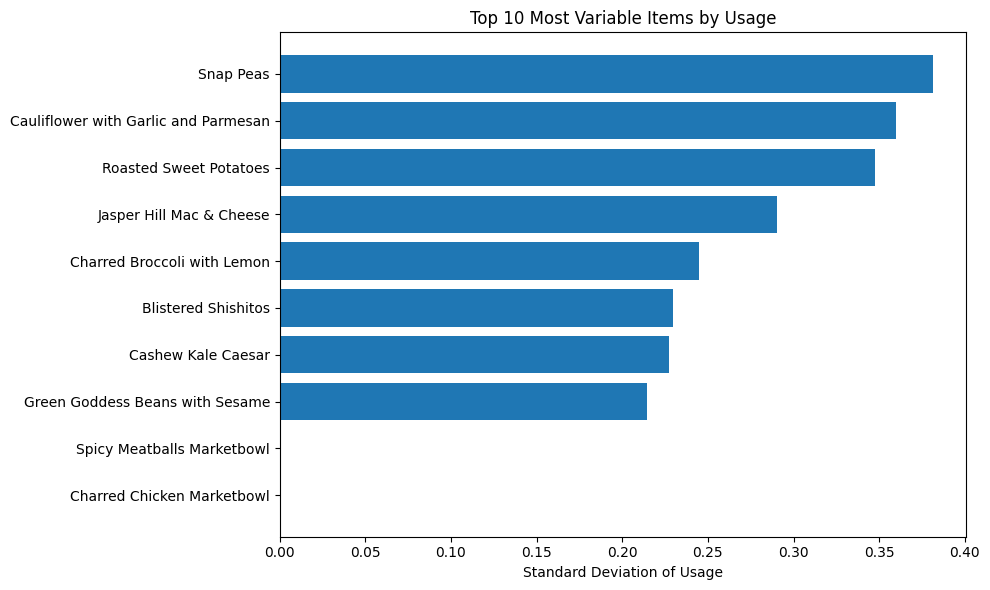

In [ ]:
import matplotlib.pyplot as plt

# Bar chart of top 10 variable items
top_var = item_var_named.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_var['ITEM_NAME'], top_var['STD_DEV'])
plt.xlabel('Standard Deviation of Usage')
plt.title('Top 10 Most Variable Items by Usage')
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

## ✅ Conclusion 15 points

In this final section, clearly and explicitly connect your analysis to your assigned business question.

> Your conclusion **must include** the following:

- **Restate your specific business question** in one sentence.
- **Explain how your analysis and visualizations directly answer that question.**
- Reference the **specific final chart, table, or summary statistic** that provides the answer.
- Comment briefly on any **key implications** for the business.
- Ensure that the referenced visualization or table is present, labeled, and interpretable by a business audience.

🎯 **Your analysis is not complete unless this section clearly demonstrates how your final output answers the business question.**



CIS 530 Final Project

Item Usage Variability Analysis

Name: Md Mukidur Rahman

Business Question:

Which items have the most variable usage, and what might that imply about supply chain stability?


To answer this question, I analyzed item-level data from the Simplified Orders dataset by counting how often each item appeared across individual customer orders. I then calculated the standard deviation of item usage across all orders to measure variability.

The final output includes a bar chart titled “Top 10 Most Variable Items by Usage”, which visually displays the items with the highest standard deviations in usage. According to this chart and the corresponding table, the top three most variable items are:
	•	Snap Peas (standard deviation ≈ 0.38)
	•	Cauliflower with Garlic and Parmesan (std dev ≈ 0.36)
	•	Roasted Sweet Potatoes (std dev ≈ 0.35)

This statistical variability means these items are ordered inconsistently across customers and time, making them harder to predict and manage in inventory.

Implications for the business: These highly variable items may require more flexible supply chain practices, such as safety stock, demand forecasting adjustments, or vendor agreements that allow for fluctuating quantities. By identifying these patterns, the business can better prepare for unpredictable demand and reduce the risk of overstocking or stockouts.

The chart and table are clearly labeled and designed for a business audience, providing direct evidence to support these conclusions.




